
1. LOADING...
   X_train: (37, 48)
   X_test:  (25, 48)
   y_train: (37,)
   y_test:  (25,)
   Features totales: 48

2. CLEANING...
   Columns after NaN filter (>50%): 48
   Columns after zero-variance filter: 48

2. SELECTING FEATURES...

   🟢 SELECTED (20 features):
   ------------------------------------------------------------
    1. Corridor_CO2_Increment_mean                   Score: 0.3303
    2. Corridor_CO2_max                              Score: 0.2190
    3. Corridor_CO2_mean                             Score: 0.2540
    4. Corridor_CO2_min                              Score: 0.3544
    5. Corridor_CO2_std                              Score: 0.2236
    6. Corridor_Humidity_Increment_min               Score: 0.3678
    7. Corridor_Temp_Increment_mean                  Score: 0.4656
    8. Corridor_Temp_Increment_min                   Score: 0.3978
    9. Corridor_Temperature_std                      Score: 0.6813
   10. Outdoor_Humidity_Outdoor_Increment_max        Score: 0.2

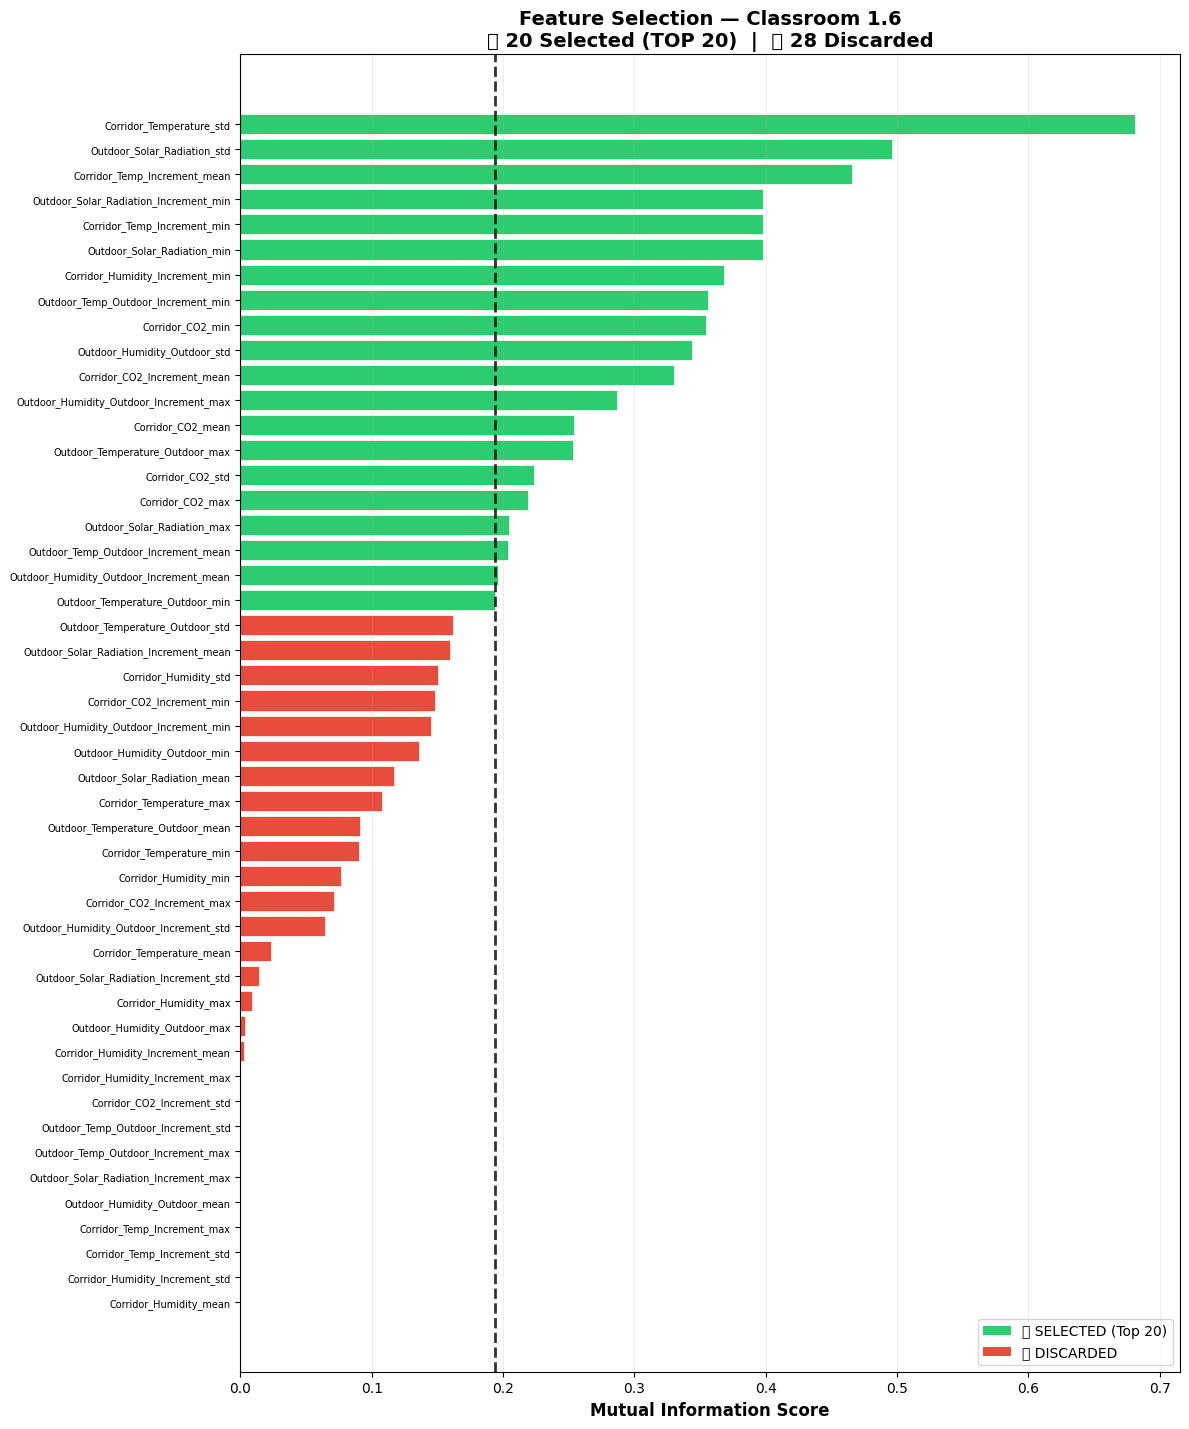

   Saved: feature_selection_scores_1_6.png

5. NORMALIZING...
   X_train_norm: (37, 20)
   X_test_norm:  (25, 20)
   Train mean (should be ~0): -0.0000
   Train std  (should be ~1): 1.0000

6. SAVING...

✅ Done! 48 → 20 features
   Saved in: ml_normalized_grouped/
   X_train.xlsx, X_test.xlsx
   X_train_normalised.xlsx, X_test_normalised.xlsx
   y_train.xlsx, y_test.xlsx
   feature_scores_all.xlsx
   scaler.pkl, selector.pkl, selected_features.pkl


In [1]:
# ===================================================================
# SISTEMA DE ANÁLISIS AMBIENTAL PARA AULA 1.6
# ===================================================================
# AUTOR: Carmen Gómez Alarcón
# FECHA: 2026
# FASE: Paso 4. Selección de características y normalización
# DESCRIPCIÓN:
#   Selecciona las mejores features y normaliza con StandardScaler.
#   Carga los archivos .xlsx generados en el Paso 3.
# ===================================================================

import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_regression
import warnings
warnings.filterwarnings('ignore')

INPUT_DIR  = 'ml_features_grouped'    # generado en Paso 3
OUTPUT_DIR = 'ml_normalized_grouped'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ===================================================================
# 1. CARGAR — .xlsx del Paso 3
# ===================================================================
print("\n1. LOADING...")

X_train = pd.read_excel(os.path.join(INPUT_DIR, 'X_train.xlsx')).values
X_test  = pd.read_excel(os.path.join(INPUT_DIR, 'X_test.xlsx')).values
y_train = pd.read_excel(os.path.join(INPUT_DIR, 'y_train.xlsx')).values.ravel()
y_test  = pd.read_excel(os.path.join(INPUT_DIR, 'y_test.xlsx')).values.ravel()

# sensor_cols.pkl guarda los nombres de columna del Paso 3
with open(os.path.join(INPUT_DIR, 'sensor_cols.pkl'), 'rb') as f:
    feature_names = pickle.load(f)

print(f"   X_train: {X_train.shape}")
print(f"   X_test:  {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test:  {y_test.shape}")
print(f"   Features totales: {len(feature_names)}")

# ===================================================================
# 2. LIMPIEZA — NaN y varianza cero
# ===================================================================
print("\n2. CLEANING...")

# Eliminar columnas con >50% NaN
nan_ratio = np.isnan(X_train).mean(axis=0)
valid_cols = nan_ratio < 0.5
X_train = X_train[:, valid_cols]
X_test  = X_test[:, valid_cols]
feature_names = [f for f, v in zip(feature_names, valid_cols) if v]
print(f"   Columns after NaN filter (>50%): {X_train.shape[1]}")

# Rellenar NaN restantes con media de train
col_means = np.nanmean(X_train, axis=0)
for j in range(X_train.shape[1]):
    X_train[np.isnan(X_train[:, j]), j] = col_means[j]
    X_test[np.isnan(X_test[:, j]),   j] = col_means[j]

# Eliminar columnas con varianza cero
nonzero_var = X_train.var(axis=0) > 0
X_train = X_train[:, nonzero_var]
X_test  = X_test[:, nonzero_var]
feature_names = [f for f, v in zip(feature_names, nonzero_var) if v]
print(f"   Columns after zero-variance filter: {X_train.shape[1]}")

# ===================================================================
# 3. SELECCIÓN DE FEATURES — mutual info regression
# ===================================================================
print("\n2. SELECTING FEATURES...")

scores = mutual_info_regression(X_train, y_train, random_state=42)

df_scores = pd.DataFrame({
    'Feature': feature_names,
    'Score': scores
}).sort_values('Score', ascending=False).reset_index(drop=True)

# K: features con score > 0.01, máximo 20
k = sum(s > 0.01 for s in scores)
k = min(k, min(20, X_train.shape[0] - 1))
if k < 1:
    k = min(5, X_train.shape[0] - 1)

selector = SelectKBest(mutual_info_regression, k=k)
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel  = selector.transform(X_test)

selected_mask      = selector.get_support()
selected_features  = np.array(feature_names)[selected_mask].tolist()
discarded_features = np.array(feature_names)[~selected_mask].tolist()

# ────────────────────────────────────────
# 🟢 SELECCIONADAS
# ────────────────────────────────────────
print(f"\n   🟢 SELECTED ({len(selected_features)} features):")
print("   " + "-"*60)
for i, feat in enumerate(selected_features, 1):
    score = df_scores[df_scores['Feature'] == feat]['Score'].values[0]
    print(f"   {i:2d}. {feat:<45s} Score: {score:.4f}")

# ────────────────────────────────────────
# 🔴 DESCARTADAS
# ────────────────────────────────────────
print(f"\n   🔴 DISCARDED ({len(discarded_features)} features):")
print("   " + "-"*60)
for i, feat in enumerate(discarded_features, 1):
    score = df_scores[df_scores['Feature'] == feat]['Score'].values[0]
    print(f"   {i:2d}. {feat:<45s} Score: {score:.4f}")

print(f"\n   📊 SUMMARY:")
print(f"   Total features: {len(feature_names)}")
print(f"   Selected:       {len(selected_features)} (score > 0.01, max 20)")
print(f"   Discarded:      {len(discarded_features)}")
print(f"   k selected:     {k}")

# ===================================================================
# 4. GRÁFICO — Feature Selection Scores
# ===================================================================
print("\n4. PLOTTING...")

df_plot = df_scores.copy()
df_plot['Status'] = np.where(df_plot.index < k, 'Selected', 'Discarded')
df_plot = df_plot.sort_values('Score', ascending=True)

n_sel  = sum(df_plot['Status'] == 'Selected')
n_disc = sum(df_plot['Status'] == 'Discarded')

fig, ax = plt.subplots(figsize=(12, max(8, len(df_plot) * 0.3)))

for i, (_, row) in enumerate(df_plot.iterrows()):
    color = '#2ecc71' if row['Status'] == 'Selected' else '#e74c3c'
    ax.barh(i, row['Score'], color=color, edgecolor='white', linewidth=0.5)

threshold_score = df_plot[df_plot['Status'] == 'Selected']['Score'].min()
ax.axvline(x=threshold_score, color='black', linestyle='--', linewidth=2, alpha=0.8,
           label=f'Threshold (top {k}) = {threshold_score:.4f}')

ax.set_yticks(range(len(df_plot)))
labels = [f[:45] + '...' if len(f) > 45 else f for f in df_plot['Feature']]
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel('Mutual Information Score', fontsize=12, fontweight='bold')
ax.set_title(f'Feature Selection — Classroom 1.6\n🟢 {n_sel} Selected (TOP {k})  |  🔴 {n_disc} Discarded',
             fontsize=14, fontweight='bold')

legend_elements = [
    Patch(facecolor='#2ecc71', label=f'🟢 SELECTED (Top {k})'),
    Patch(facecolor='#e74c3c', label=f'🔴 DISCARDED'),
]
ax.legend(handles=legend_elements, fontsize=10, loc='lower right')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig('feature_selection_scores_1_6.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"   Saved: feature_selection_scores_1_6.png")

# ===================================================================
# 5. NORMALIZACIÓN — StandardScaler ajustado solo en train
# ===================================================================
print("\n5. NORMALIZING...")

scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train_sel)   # fit solo en train
X_test_norm  = scaler.transform(X_test_sel)         # solo transform en test

print(f"   X_train_norm: {X_train_norm.shape}")
print(f"   X_test_norm:  {X_test_norm.shape}")
print(f"   Train mean (should be ~0): {X_train_norm.mean():.4f}")
print(f"   Train std  (should be ~1): {X_train_norm.std():.4f}")

# ===================================================================
# 6. GUARDAR EN XLSX
# ===================================================================
print("\n6. SAVING...")

pd.DataFrame(X_train_sel,  columns=selected_features).to_excel(os.path.join(OUTPUT_DIR, 'X_train.xlsx'),            index=False)
pd.DataFrame(X_test_sel,   columns=selected_features).to_excel(os.path.join(OUTPUT_DIR, 'X_test.xlsx'),             index=False)
pd.DataFrame(X_train_norm, columns=selected_features).to_excel(os.path.join(OUTPUT_DIR, 'X_train_normalised.xlsx'), index=False)
pd.DataFrame(X_test_norm,  columns=selected_features).to_excel(os.path.join(OUTPUT_DIR, 'X_test_normalised.xlsx'),  index=False)
pd.DataFrame({'Occupancy': y_train}).to_excel(os.path.join(OUTPUT_DIR, 'y_train.xlsx'), index=False)
pd.DataFrame({'Occupancy': y_test}).to_excel(os.path.join(OUTPUT_DIR,  'y_test.xlsx'),  index=False)
df_scores.to_excel(os.path.join(OUTPUT_DIR, 'feature_scores_all.xlsx'), index=False)

with open(os.path.join(OUTPUT_DIR, 'scaler.pkl'),            'wb') as f: pickle.dump(scaler,            f)
with open(os.path.join(OUTPUT_DIR, 'selector.pkl'),          'wb') as f: pickle.dump(selector,          f)
with open(os.path.join(OUTPUT_DIR, 'selected_features.pkl'), 'wb') as f: pickle.dump(selected_features, f)

print(f"\n✅ Done! {len(feature_names)} → {len(selected_features)} features")
print(f"   Saved in: {OUTPUT_DIR}/")
print(f"   X_train.xlsx, X_test.xlsx")
print(f"   X_train_normalised.xlsx, X_test_normalised.xlsx")
print(f"   y_train.xlsx, y_test.xlsx")
print(f"   feature_scores_all.xlsx")
print(f"   scaler.pkl, selector.pkl, selected_features.pkl")